# Era 2: Jupyter Notebooks (2014-present)

**The game-changer for data scientists.**

Jupyter spun off from IPython in 2014, and by 2018 there were 2.5 million notebooks on GitHub.

Instead of writing a big script and running it all at once, we can now:
- Explore data **cell by cell**
- See plots **inline** — no more saving PNGs and opening them
- Mix **narrative text** with code
- Quickly iterate: change one thing, re-run just that cell

Let's do the same marketing analysis, but interactively.

In [6]:
# First cell: imports — we discovered pandas!
import pandas as pd
import matplotlib.pyplot as plt

# This magic command makes plots show up right in the notebook
%matplotlib inline

# Make plots look a bit nicer
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

In [7]:
# One line to load data — compare this to Era 1's 10+ lines!
df = pd.read_csv('data/marketing_campaign.csv')

# And we can just... look at it. Right here.
df.head(10)

,date,channel,campaign_name,impressions,clicks,conversions,spend,revenue
0,2023-01-01,Email,Newsletter_Weekly,1392,30,1,13.34,117.06
1,2023-01-01,Display,Lookalike_Audience,5937,18,0,4.54,0.00
2,2023-01-01,Search,Product_Category,570,39,6,78.25,754.36
3,2023-01-01,Social,Influencer_Collab,4514,33,0,35.37,0.00
4,2023-01-04,Search,Product_Category,1213,71,8,201.22,362.65
5,2023-01-04,Social,Product_Launch_IG,6503,90,1,96.25,61.17
6,2023-01-04,Display,Contextual_Targeting,11149,51,0,16.13,0.00
7,2023-01-04,Email,Onboarding_Drip,2208,91,7,54.11,506.22
8,2023-01-08,Email,Newsletter_Weekly,1149,53,5,23.53,327.68
9,2023-01-08,Social,Retargeting_TikTok,3722,27,0,29.39,0.00


## Quick Data Exploration
Before we even start analyzing, let's understand what we're working with.
In the terminal days, we'd have to `print()` everything.

In [8]:
# Shape, types, basic stats — all built into pandas
print(f"Dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")
print(f"\nChannels: {df['channel'].unique().tolist()}")
df.describe()

Dataset: 840 rows x 8 columns

Date range: 2023-01-01 to 2024-12-29

Channels: ['Email', 'Display', 'Search', 'Social']


,impressions,clicks,conversions,spend,revenue
count,840.000000,840.000000,840.000000,840.000000,840.000000
mean,5337.854762,68.389286,3.746429,81.107488,320.807048
std,4806.881453,34.339740,3.811561,75.231739,382.869380
min,477.000000,16.000000,0.000000,4.270000,0.000000
25%,1444.000000,45.000000,1.000000,19.297500,30.655000
50%,3486.000000,62.000000,3.000000,55.600000,183.735000
75%,8127.250000,87.000000,6.000000,126.035000,453.400000
max,38801.000000,360.000000,21.000000,426.970000,2500.840000


In [9]:
# Check for missing values — something we probably forgot in Era 1
from IPython.core import display_functions
df.isnull().sum()

date             0
channel          0
campaign_name    0
impressions      0
clicks           0
conversions      0
spend            0
revenue          0
dtype: int64

## Channel Performance Analysis
In Era 1 this was ~30 lines of manual dictionary aggregation.
With pandas, it's one line.

In [10]:
# The magic of groupby — one line replaces 30 lines from Era 1
channel_summary = df.groupby('channel').agg({
    'spend': 'sum',
    'revenue': 'sum',
    'clicks': 'sum',
    'impressions': 'sum',
    'conversions': 'sum'
}).round(2)

# Calculate derived metrics
channel_summary['ROI (%)'] = ((channel_summary['revenue'] - channel_summary['spend']) / channel_summary['spend'] * 100).round(1)
channel_summary['CTR (%)'] = (channel_summary['clicks'] / channel_summary['impressions'] * 100).round(2)

channel_summary

,spend,revenue,clicks,impressions,conversions,ROI (%),CTR (%)
channel,,,,,,,
Display,2719.35,2404.85,9173,2329187,27,-11.6,0.39
Email,7559.88,95588.52,15432,436389,1088,1164.4,3.54
Search,37043.07,139744.83,15016,235739,1629,277.2,6.37
Social,20807.99,31739.72,17826,1482483,403,52.5,1.20


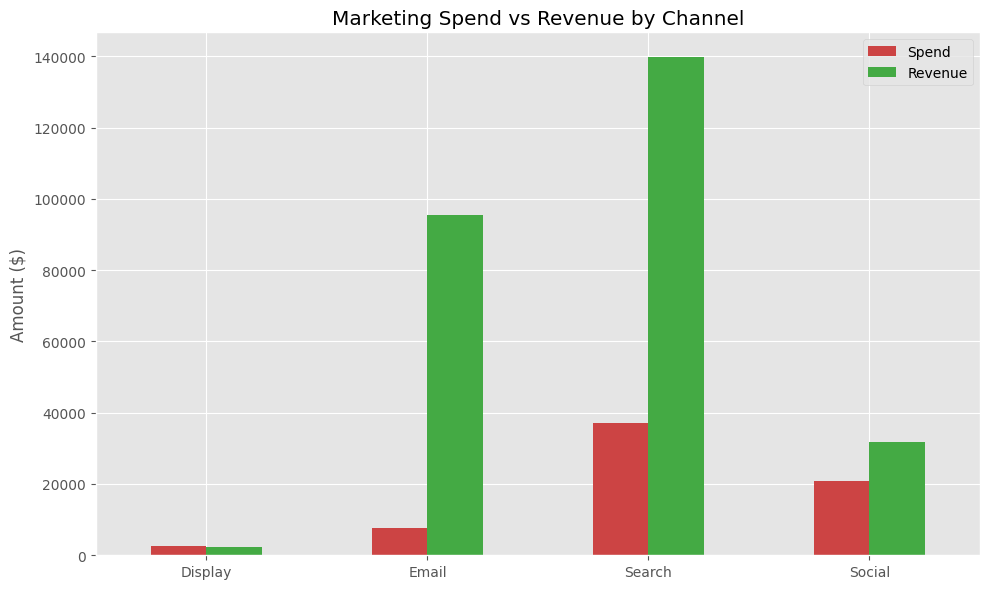

In [11]:
# Plot 1: Spend vs Revenue — so much simpler now
channel_summary[['spend', 'revenue']].plot(kind='bar', color=['#cc4444', '#44aa44'])
plt.title('Marketing Spend vs Revenue by Channel')
plt.ylabel('Amount ($)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(['Spend', 'Revenue'])
plt.tight_layout()
plt.savefig('plots/era2_spend_vs_revenue.png', dpi=100)
plt.show()

## Monthly Revenue Trend
With pandas datetime support, time series analysis becomes natural.

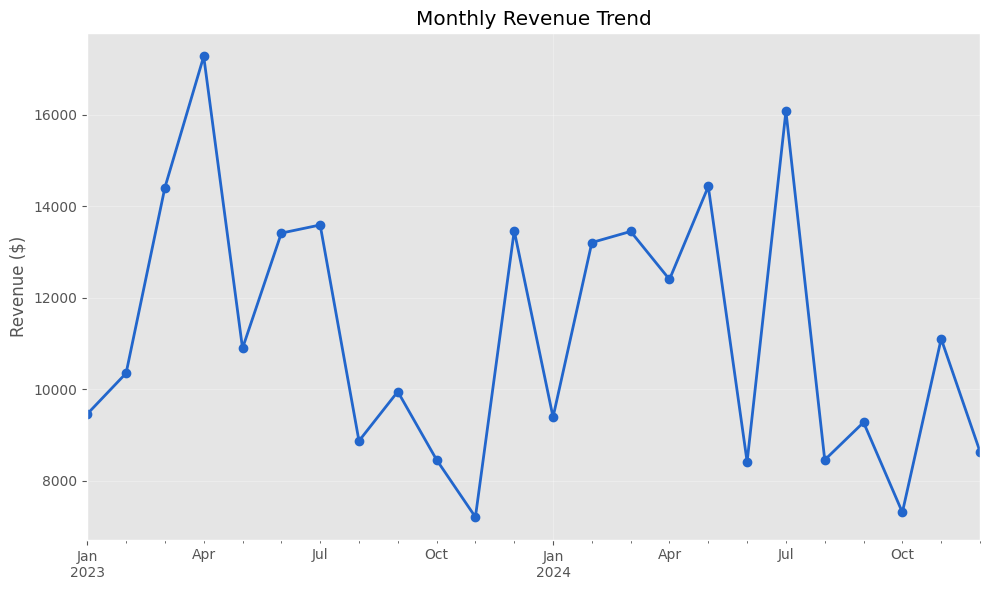

In [12]:
# Convert to datetime and aggregate by month
df['date'] = pd.to_datetime(df['date'])
monthly = df.resample('ME', on='date')['revenue'].sum()

# Plot it — two lines!
monthly.plot(marker='o', linewidth=2, color='#2266cc')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue ($)')
plt.xlabel('')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/era2_monthly_revenue.png', dpi=100)
plt.show()

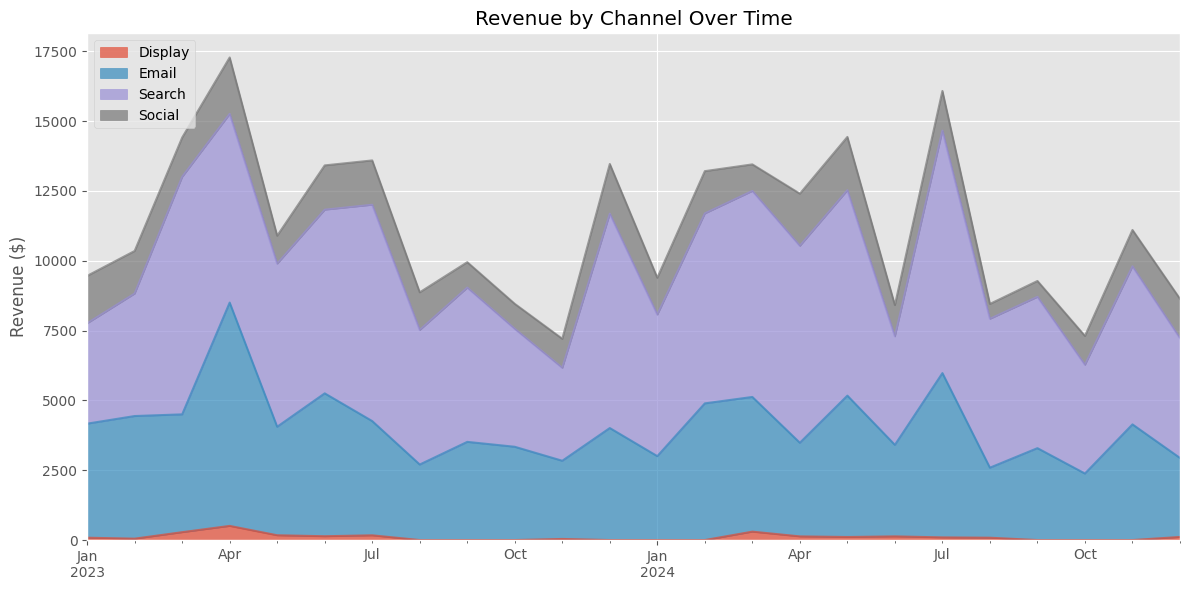

In [13]:
# Bonus: something we wouldn't have tried in Era 1 because it was too much work
# Revenue by channel over time — a pivot table + plot
monthly_by_channel = df.pivot_table(
    values='revenue', 
    index=df['date'].dt.to_period('M'),
    columns='channel',
    aggfunc='sum'
)

monthly_by_channel.plot(kind='area', stacked=True, alpha=0.7, figsize=(12, 6))
plt.title('Revenue by Channel Over Time')
plt.ylabel('Revenue ($)')
plt.xlabel('')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('plots/era2_revenue_by_channel.png', dpi=100)
plt.show()

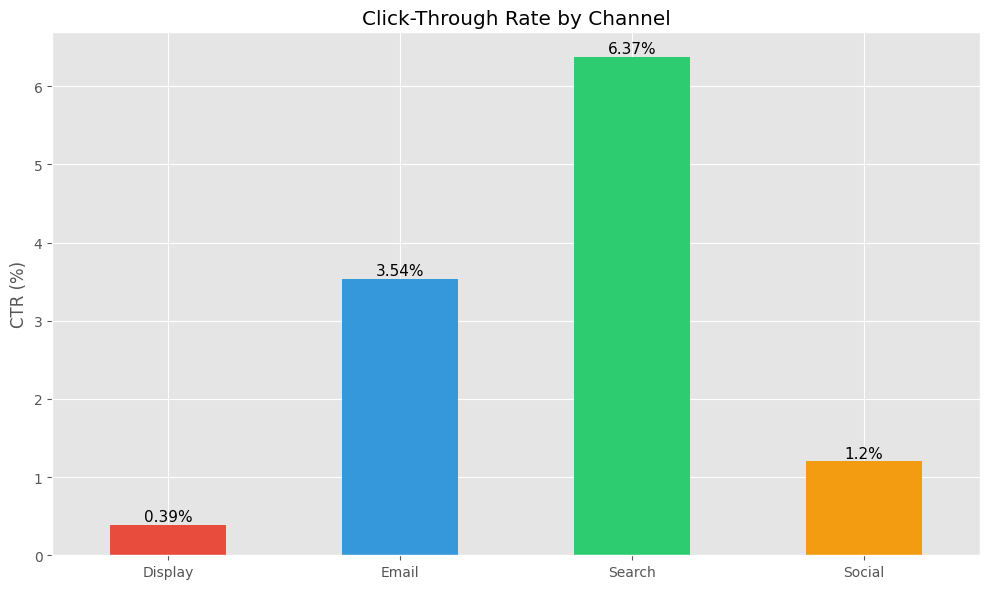

In [14]:
# CTR by channel — bar chart with values on top
ax = channel_summary['CTR (%)'].plot(kind='bar', color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])
plt.title('Click-Through Rate by Channel')
plt.ylabel('CTR (%)')
plt.xlabel('')
plt.xticks(rotation=0)

for i, v in enumerate(channel_summary['CTR (%)']):
    ax.text(i, v + 0.05, f'{v}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('plots/era2_ctr_by_channel.png', dpi=100)
plt.show()

## Key Takeaway

**Era 1 → Era 2 was the biggest productivity jump for data scientists.**

- Went from ~160 lines to ~50 lines for the same output
- Interactive exploration: try things, see results, iterate
- Inline plots: no more switching between terminal and image viewer
- Pandas does the heavy lifting: `groupby`, `resample`, `pivot_table`
- But: still writing all the code yourself, still need to know the APIs